Project Planning



In [ ]:
#Problem Statement
problem_statement = """
Customers are leaving the company (churn), leading to revenue loss.
We need to identify the key factors causing churn and suggest strategies to reduce it.
"""
print(problem_statement)


Customers are leaving the company (churn), leading to revenue loss.
We need to identify the key factors causing churn and suggest strategies to reduce it.



In [ ]:
#Objectives
objectives = [
    "Analyze customer behavior",
    "Identify factors affecting churn",
    "Build predictive understanding",
    "Provide business recommendations"
]
objectives

['Analyze customer behavior',
 'Identify factors affecting churn',
 'Build predictive understanding',
 'Provide business recommendations']

In [5]:
#Success Metrics
success_metrics = {
    "Target": "Reduce churn by 15-20%",
    "Model Accuracy (if ML used)": ">75%",
    "Business Impact": "Improve retention"
}
success_metrics

{'Target': 'Reduce churn by 15-20%',
 'Model Accuracy (if ML used)': '>75%',
 'Business Impact': 'Improve retention'}

 Data Collection & Preparation

In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#Load Dataset
from google.colab import files
uploaded = files.upload()

Saving customer_churn (1).csv to customer_churn (1).csv


In [19]:
import pandas as pd
df = pd.read_csv("customer_churn (1).csv")


df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [7]:
#Basic Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [8]:
#Check Missing Values
df.isnull().sum()

,0
CustomerID,0
Tenure,0
MonthlyCharges,0
TotalCharges,0
Contract,0
PaymentMethod,0
PaperlessBilling,0
SeniorCitizen,0
Churn,0


In [9]:
#Data Cleanin       ,Remove duplicates
df = df.drop_duplicates()

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
#Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [20]:
#Encode Target Variable
import pandas as pd
df = pd.read_csv("customer_churn (1).csv")
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Exploratory Data Analysis (EDA)

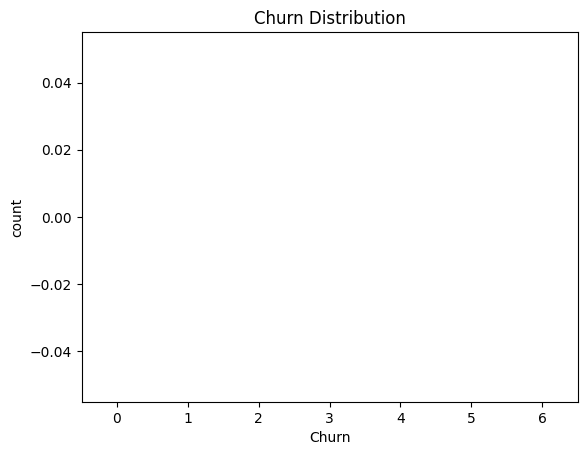

In [21]:
#Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [22]:
#Churn by Gender
# The column 'gender' does not exist in the DataFrame.
# Let's check the available columns.
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv("customer_churn (1).csv")
print(df.columns)

Saving customer_churn (1).csv to customer_churn (1) (1).csv
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')


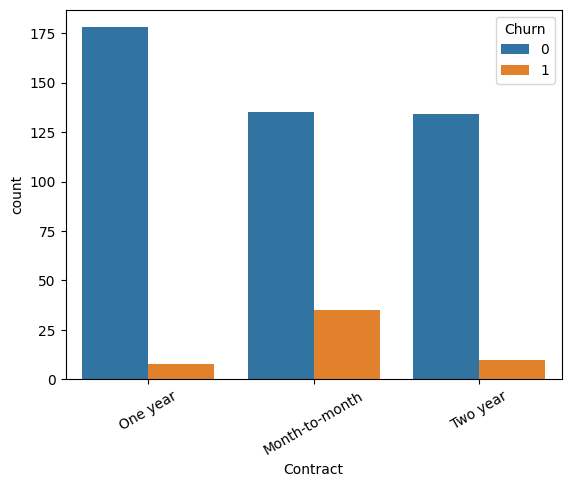

In [23]:
#Churn vs Contract Type
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

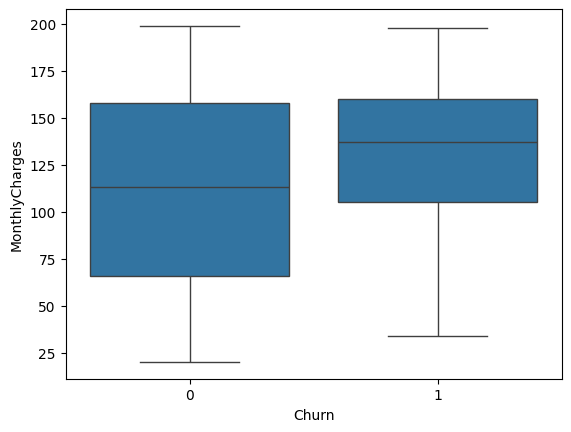

In [24]:
#Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

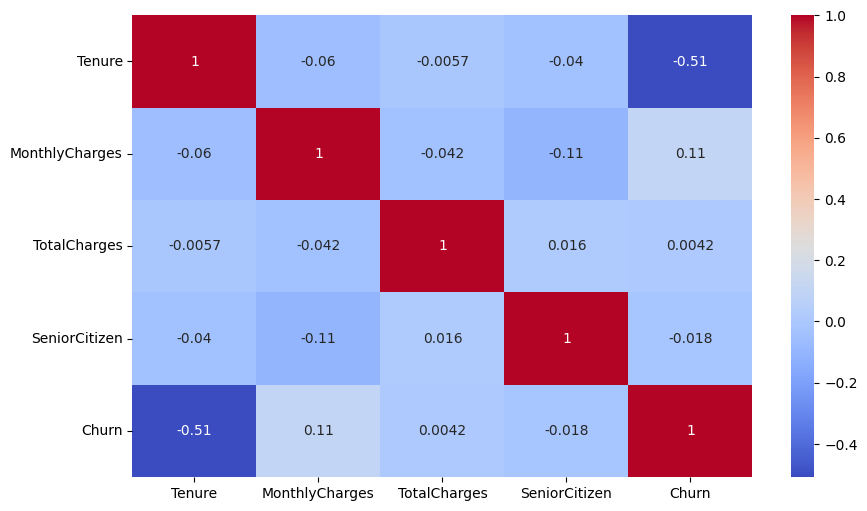

In [25]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Advanced Analysis

In [26]:
#Hypothesis Testing Example
from scipy.stats import ttest_ind

churn_yes = df[df['Churn'] == 1]['MonthlyCharges']
churn_no = df[df['Churn'] == 0]['MonthlyCharges']

t_stat, p_val = ttest_ind(churn_yes, churn_no)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 2.4102471700825414
P-value: 0.016303157985223953


In [27]:
#Logistic Regression (Optional but Powerful)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.96


 Insights & Recommendations

In [28]:
insights = [
    "Month-to-month contracts have highest churn",
    "High monthly charges increase churn probability",
    "Long-term customers are more loyal"
]
insights

['Month-to-month contracts have highest churn',
 'High monthly charges increase churn probability',
 'Long-term customers are more loyal']

In [29]:
#Business Recommendations
recommendations = [
    "Offer discounts for long-term contracts",
    "Provide loyalty rewards",
    "Target high-risk customers with offers",
    "Improve customer service for new users"
]
recommendations

['Offer discounts for long-term contracts',
 'Provide loyalty rewards',
 'Target high-risk customers with offers',
 'Improve customer service for new users']

In [30]:
#Implementation Plan
implementation = {
    "Short Term": "Offer discounts to churn-prone users",
    "Medium Term": "Improve onboarding experience",
    "Long Term": "Build predictive churn system"
}
implementation

{'Short Term': 'Offer discounts to churn-prone users',
 'Medium Term': 'Improve onboarding experience',
 'Long Term': 'Build predictive churn system'}

In [31]:
#Executive Summary (Write This)
"""
This project analyzes customer churn behavior and identifies key factors influencing churn.
The analysis shows that contract type, monthly charges, and tenure significantly impact churn.

Recommendations include:
- Promoting long-term contracts
- Reducing cost burden
- Improving customer retention strategies

Expected Impact: 15-20% reduction in churn.
"""

'\nThis project analyzes customer churn behavior and identifies key factors influencing churn.\nThe analysis shows that contract type, monthly charges, and tenure significantly impact churn.\n\nRecommendations include:\n- Promoting long-term contracts\n- Reducing cost burden\n- Improving customer retention strategies\n\nExpected Impact: 15-20% reduction in churn.\n'